In [1]:
import pandas as pd
import gseapy as gp
from mygene import MyGeneInfo
import matplotlib.pyplot as plt

In [2]:
res_cm = pd.read_csv("Anotacao_cardio.csv", index_col=0)

res_ph = pd.read_csv("Anotacao_poli.csv", index_col=0)

In [3]:
cm_1 = list(res_cm.loc[res_cm['cluster']==1,].index)
cm_2 = list(res_cm.loc[res_cm['cluster']==2,].index)
cm_4 = list(res_cm.loc[res_cm['cluster']==4,].index)

In [4]:
ph_1 = list(res_ph.loc[res_ph['cluster']==1,].index)
ph_4 = list(res_ph.loc[res_ph['cluster']==4,].index)
ph_12 = list(res_ph.loc[res_ph['cluster']==12,].index)

In [5]:
mg = MyGeneInfo()

In [8]:
def anotation(ls,mg):
    cutoffs_final = []
    
    query = mg.querymany(
        ls,
        scopes='ensembl.transcript',
        fields='symbol',
        species='human'
    )

    query_df = pd.DataFrame(query)
    symbols = query_df['symbol'].dropna().unique().tolist()
    
    try:
        # Biological Process
        go = gp.enrichr(
            gene_list=symbols,
            gene_sets='GO_Biological_Process_2023',
            organism='human',
            outdir='GO_BP',
            cutoff=0.01
        )
        cutoffs_final.append(0.01)
        
    except:
        for i in [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]:
            try:
                go = gp.enrichr(
                    gene_list=symbols,
                    gene_sets='GO_Biological_Process_2023',
                    organism='human',
                    outdir='GO_BP',
                    cutoff=i
                )
                cutoffs_final.append(i)
                break
            except:
                continue

    try:
       # KEGG
        kegg = gp.enrichr(
            gene_list=symbols,
            gene_sets='KEGG_2021_Human',
            organism='human',
            outdir='GO_BP',
            cutoff=0.01
        )
        cutoffs_final.append(0.01)
        
    except:
        for i in [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]:
            try:
                kegg = gp.enrichr(
                    gene_list=symbols,
                    gene_sets='KEGG_2021_Human',
                    organism='human',
                    outdir='GO_BP',
                    cutoff=i
                )
                cutoffs_final.append(i)
                break
            except:
                continue

    try:
        # REACTOME
        reactome = gp.enrichr(
            gene_list=symbols,
            gene_sets='Reactome_2022',
            organism='human',
            outdir='GO_BP',
            cutoff=0.01
        )
        cutoffs_final.append(0.01)
        
    except:
        for i in [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]:
            try:
                reactome = gp.enrichr(
                    gene_list=symbols,
                    gene_sets='Reactome_2022',
                    organism='human',
                    outdir='GO_BP',
                    cutoff=i
                )
                cutoffs_final.append(i)
                break
            except:
                continue

    try:
        # MSIGDB
        hallmark = gp.enrichr(
            gene_list=symbols,
            gene_sets='MSigDB_Hallmark_2020',
            organism='human',
            outdir='GO_BP',
            cutoff=0.01
        )
        cutoffs_final.append(0.01)
        
    except:
        for i in [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]:
            try:
                hallmark = gp.enrichr(
                    gene_list=symbols,
                    gene_sets='MSigDB_Hallmark_2020',
                    organism='human',
                    outdir='GO_BP',
                    cutoff=i
                )
                cutoffs_final.append(i)
                break
            except:
                continue

    return [[go, kegg, reactome, hallmark,],[cutoffs_final]]

In [11]:
cm_1_ano, cm_1_cut = anotation(cm_1, mg)[0], anotation(cm_1, mg)[1]
cm_2_ano, cm_2_cut = anotation(cm_2, mg)[0], anotation(cm_2, mg)[1]
cm_4_ano, cm_4_cut = anotation(cm_4, mg)[0], anotation(cm_4, mg)[1]

ph_1_ano, ph_1_cut = anotation(ph_1, mg)[0], anotation(ph_1, mg)[1]
ph_4_ano, ph_4_cut = anotation(ph_4, mg)[0], anotation(ph_4, mg)[1]
ph_12_ano, ph_12_cut = anotation(ph_12, mg)[0], anotation(ph_12, mg)[1]

1 input query terms found no hit:	['ENST00000884618']
1 input query terms found no hit:	['ENST00000884618']


In [12]:
def anotation(ls, cutoffs, mg):
    # ENST -> GENE SYMBOL
    query = mg.querymany(
        ls,
        scopes='ensembl.transcript',
        fields='symbol',
        species='human'
    )

    query_df = pd.DataFrame(query)
    symbols = query_df['symbol'].dropna().unique().tolist()

    # Biological Process
    go = gp.enrichr(
        gene_list=symbols,
        gene_sets='GO_Biological_Process_2023',
        organism='human',
        outdir='GO_BP',
        cutoff=cutoffs[0]
    )

    # KEGG
    kegg = gp.enrichr(
        gene_list=symbols,
        gene_sets='KEGG_2021_Human',
        organism='human',
        outdir='KEGG',
        cutoff=cutoffs[1]
    )

    # REACTOME
    reactome = gp.enrichr(
        gene_list=symbols,
        gene_sets='Reactome_2022',
        organism='human',
        outdir='Reactome_Results',
        cutoff=cutoffs[2]
    )

    # MSIGDB
    hallmark = gp.enrichr(
        gene_list=symbols,
        gene_sets='MSigDB_Hallmark_2020',
        organism='human',
        outdir='Hallmark_Results',
        cutoff=cutoffs[3]
    )

    return (go, kegg, reactome, hallmark)

In [32]:
def plots_anot(anotation,cutoffs,title):
    
    #BP
    go_sig = anotation[0].results[anotation[0].results["Adjusted P-value"] < cutoffs[0][0]]
    go_sig_sort = go_sig.sort_values(by="Adjusted P-value")
    gp.dotplot(go_sig_sort.head(20),
               figsize=(10,10),
               cutoff = cutoffs[0][0],
               title = "GO Biological Process "+"("+title+")")
    plt.savefig("GO_"+title+'.svg',format="svg", bbox_inches="tight")


    # KEGG
    kegg_sig = anotation[1].results[anotation[1].results["Adjusted P-value"] < cutoffs[0][1]]
    kegg_sig_sort = kegg_sig.sort_values(by="Adjusted P-value")
    kegg_sig_sort.head()
    gp.dotplot(kegg_sig_sort.head(20),
               figsize=(10,10),
               cutoff = cutoffs[0][1],
               title="KEGG Pathways "+"("+title+")")
    plt.tight_layout()
    plt.savefig("KEGG_"+title+'.svg',format="svg", bbox_inches="tight")

    # REACTOME
    reactome_sig = anotation[2].results[anotation[2].results["Adjusted P-value"] < cutoffs[0][2]]
    reactome_sig_sort = reactome_sig.sort_values(by="Adjusted P-value")
    reactome_sig_sort.head()
    gp.dotplot(reactome_sig_sort.head(20), 
               figsize=(10,10),
               cutoff = cutoffs[0][2],
               title='Reactome Pathways '+"("+title+")")
    plt.tight_layout()
    plt.savefig("REACTOME_"+title+'.svg',format="svg", bbox_inches="tight", dpi = 1200)

    # MSIGDB
    hallmark_sig = anotation[3].results[anotation[3].results["Adjusted P-value"] < cutoffs[0][3]]
    hallmark_sig_sort = hallmark_sig.sort_values(by="Adjusted P-value")
    hallmark_sig_sort.head()
    gp.dotplot(hallmark_sig.head(20),
               figsize=(10,10),
               cutoff = cutoffs[0][3],
               title='Hallmark Pathways '+"("+title+")")
    plt.tight_layout()
    plt.savefig("MSIGDB_"+title+'.svg',format="svg", bbox_inches="tight")

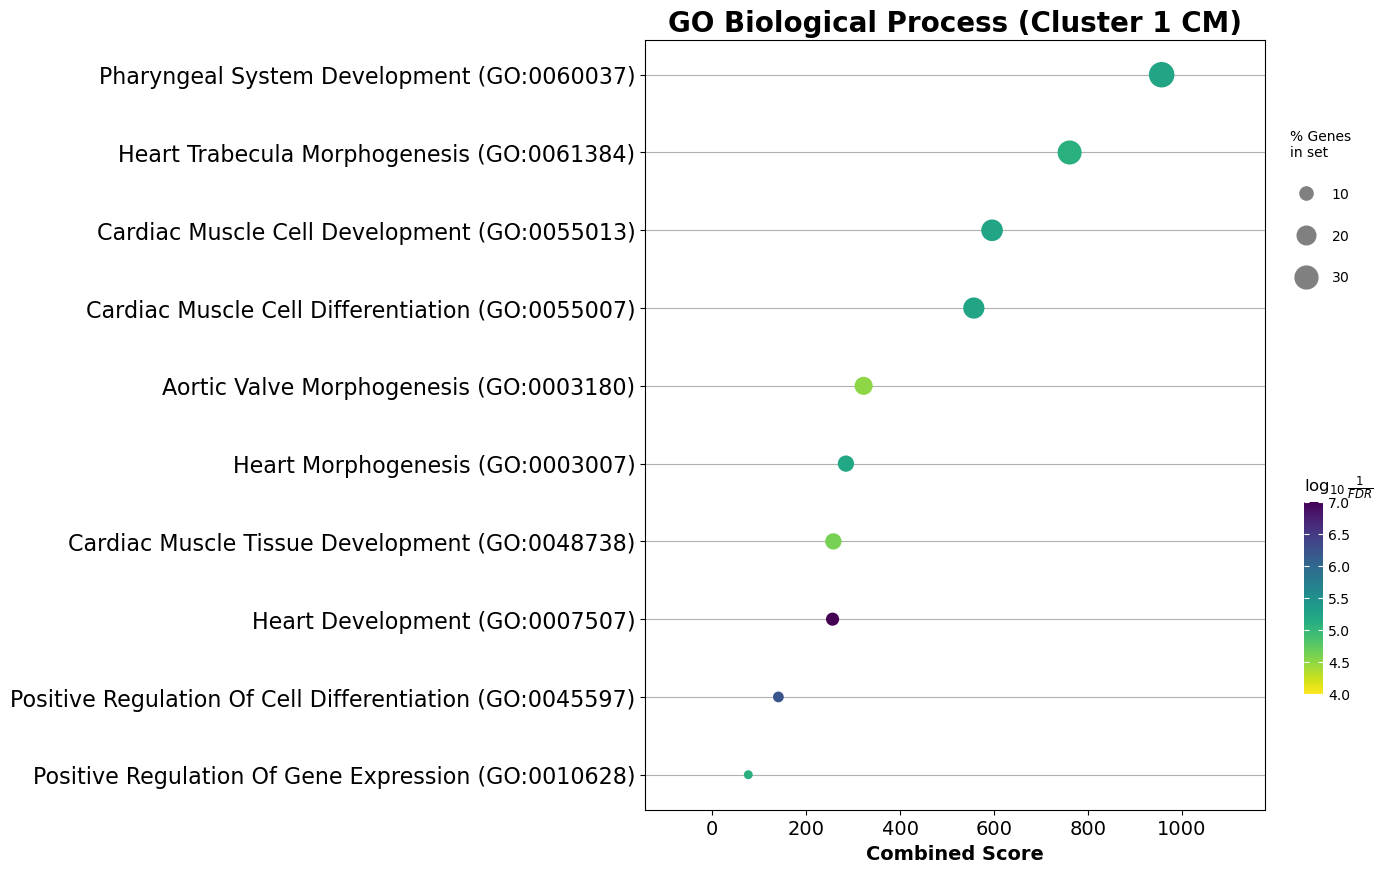

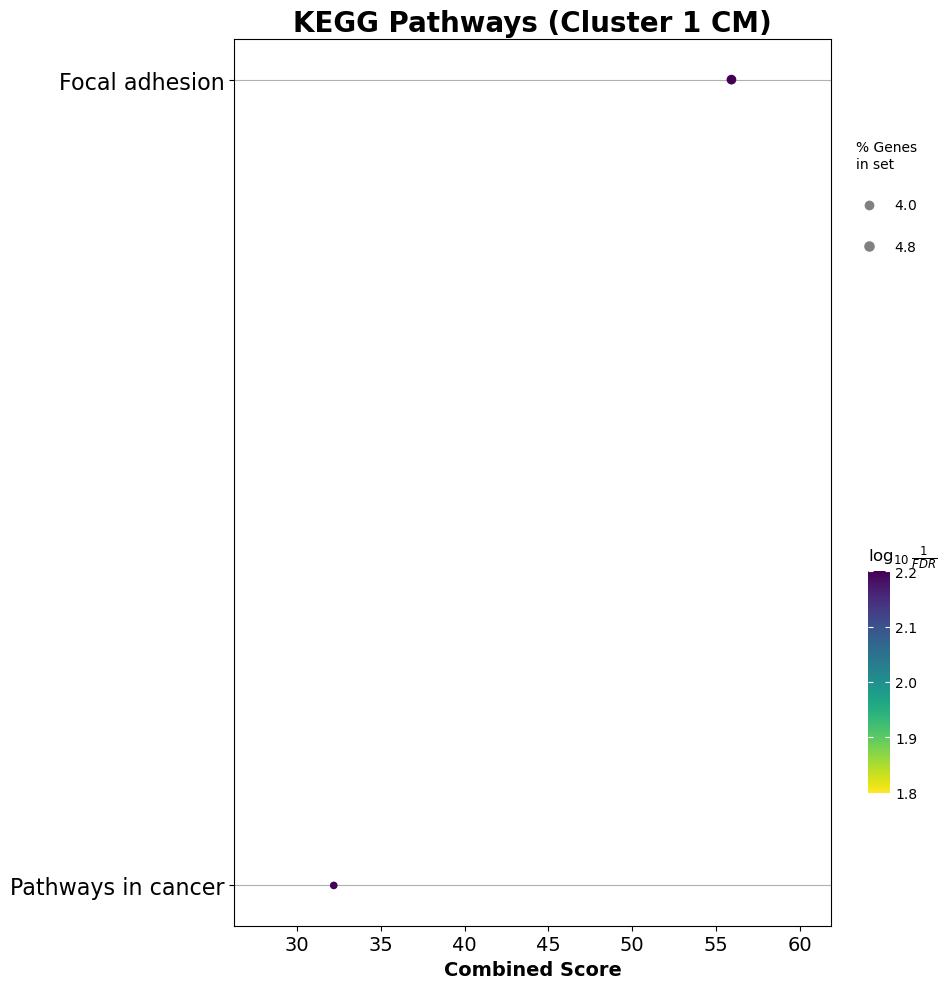

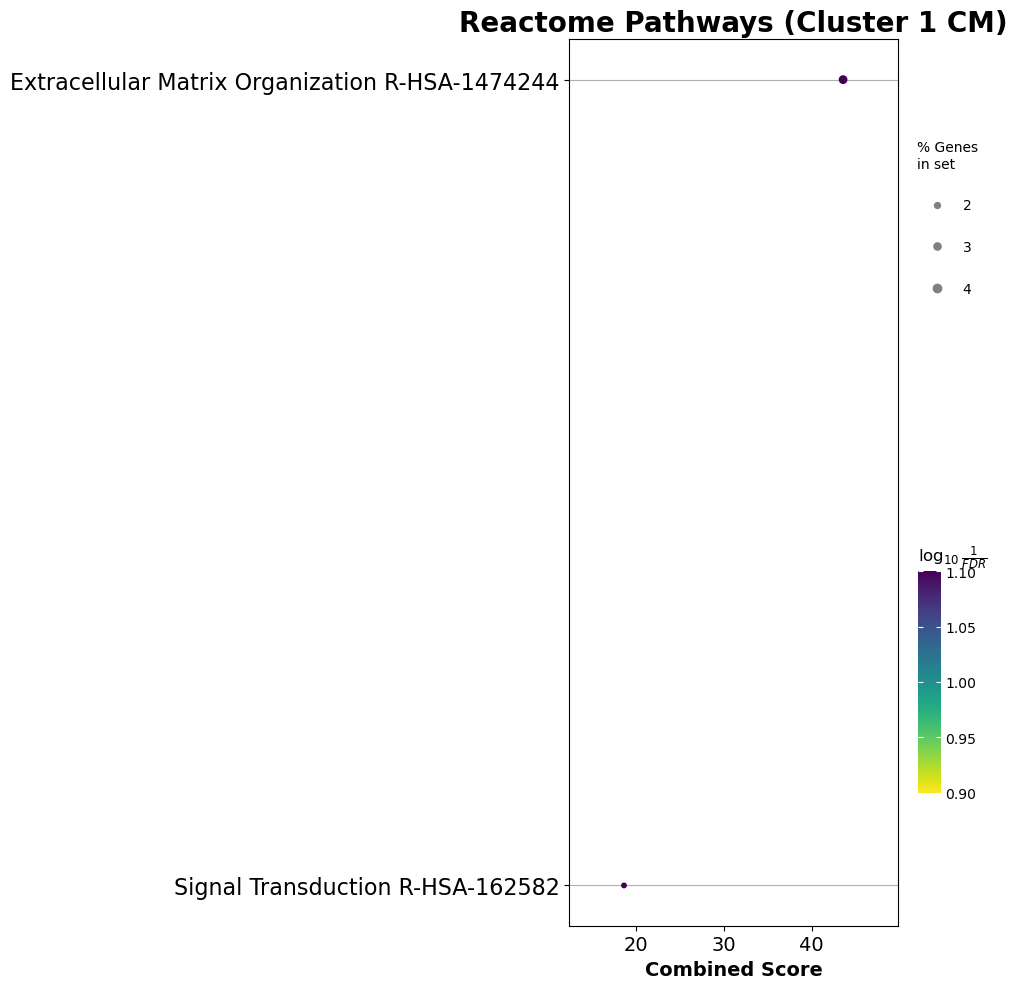

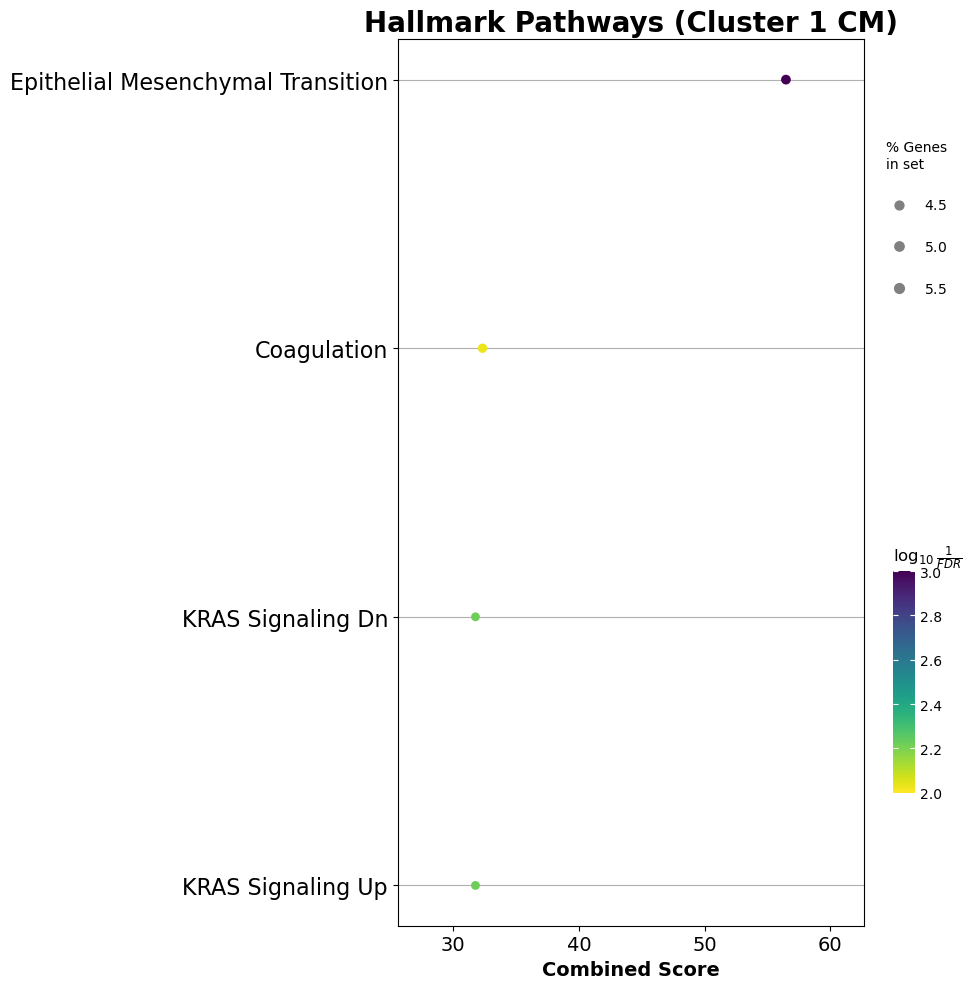

In [33]:
plots_anot(cm_1_ano,cm_1_cut,"Cluster 1 CM")

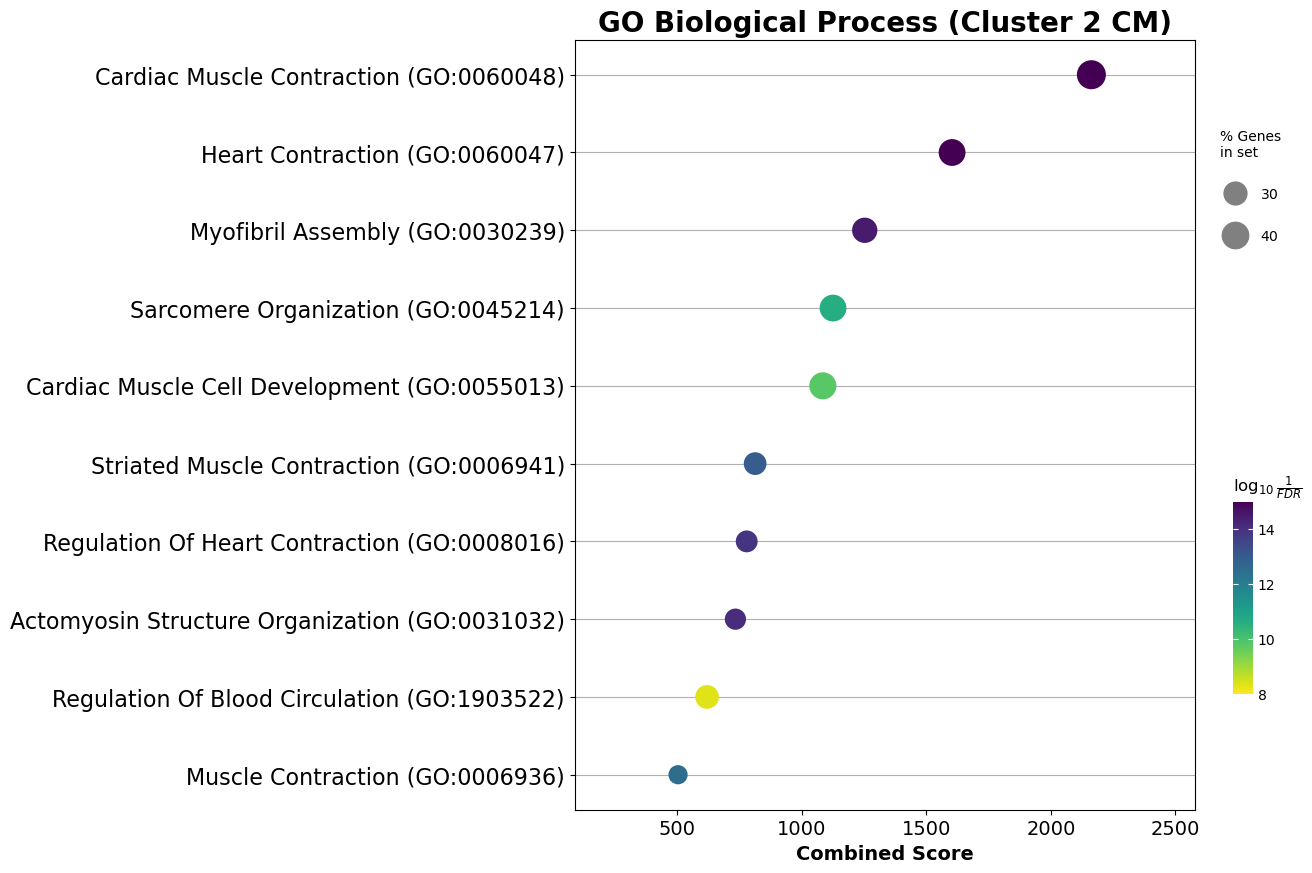

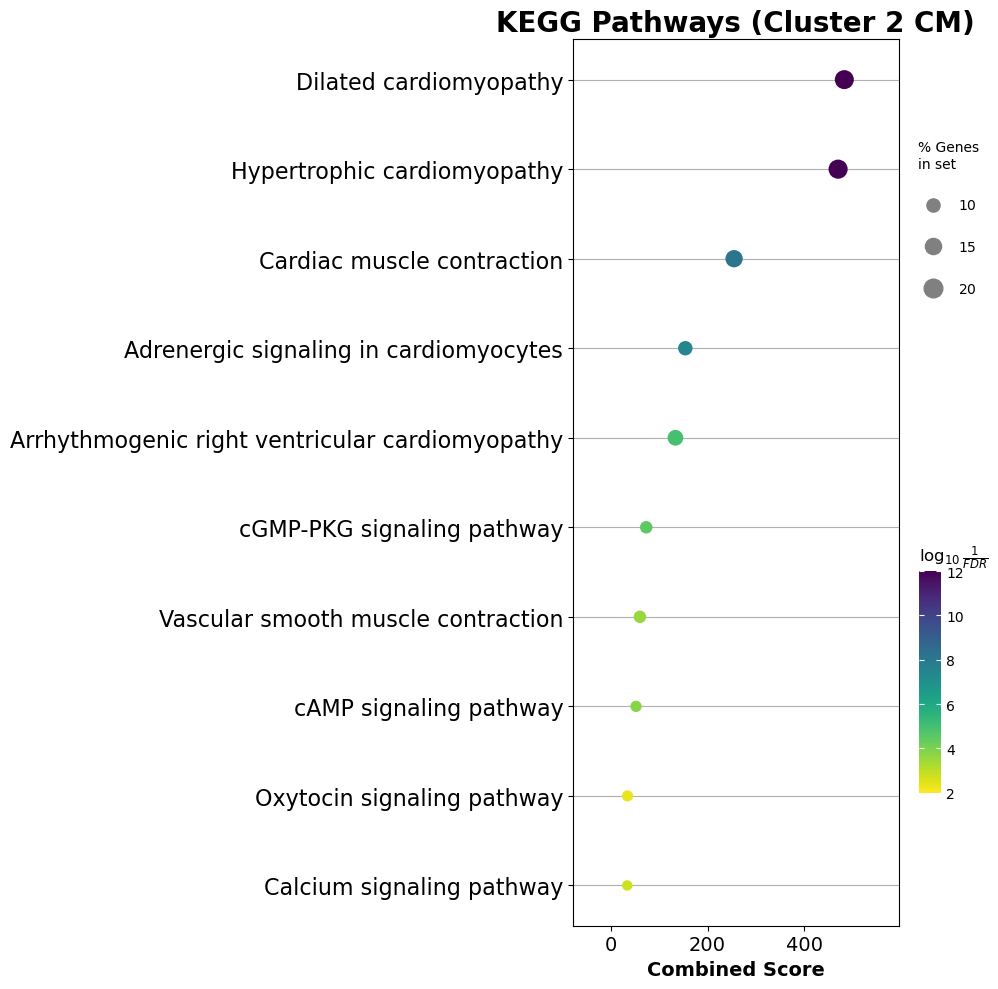

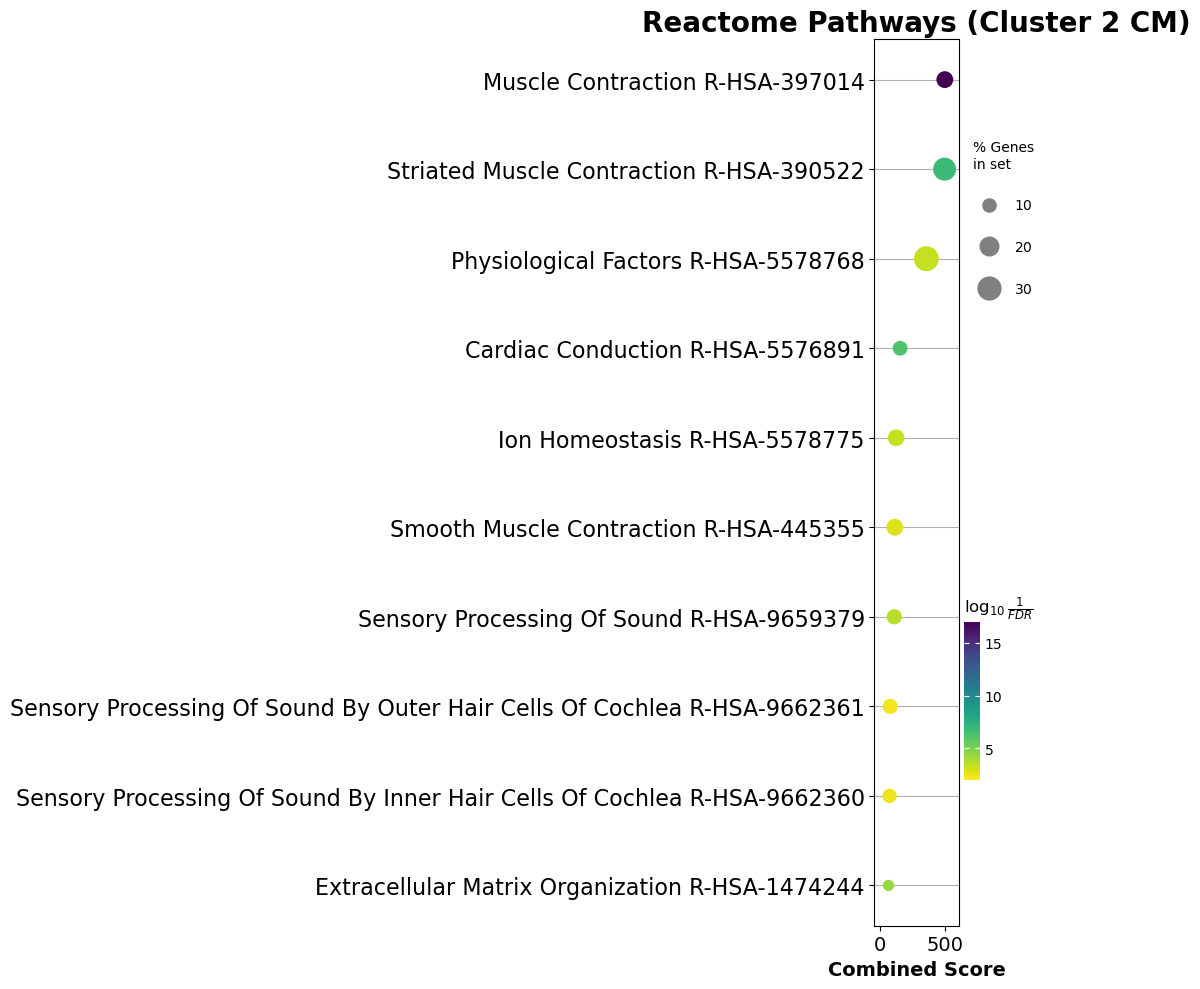

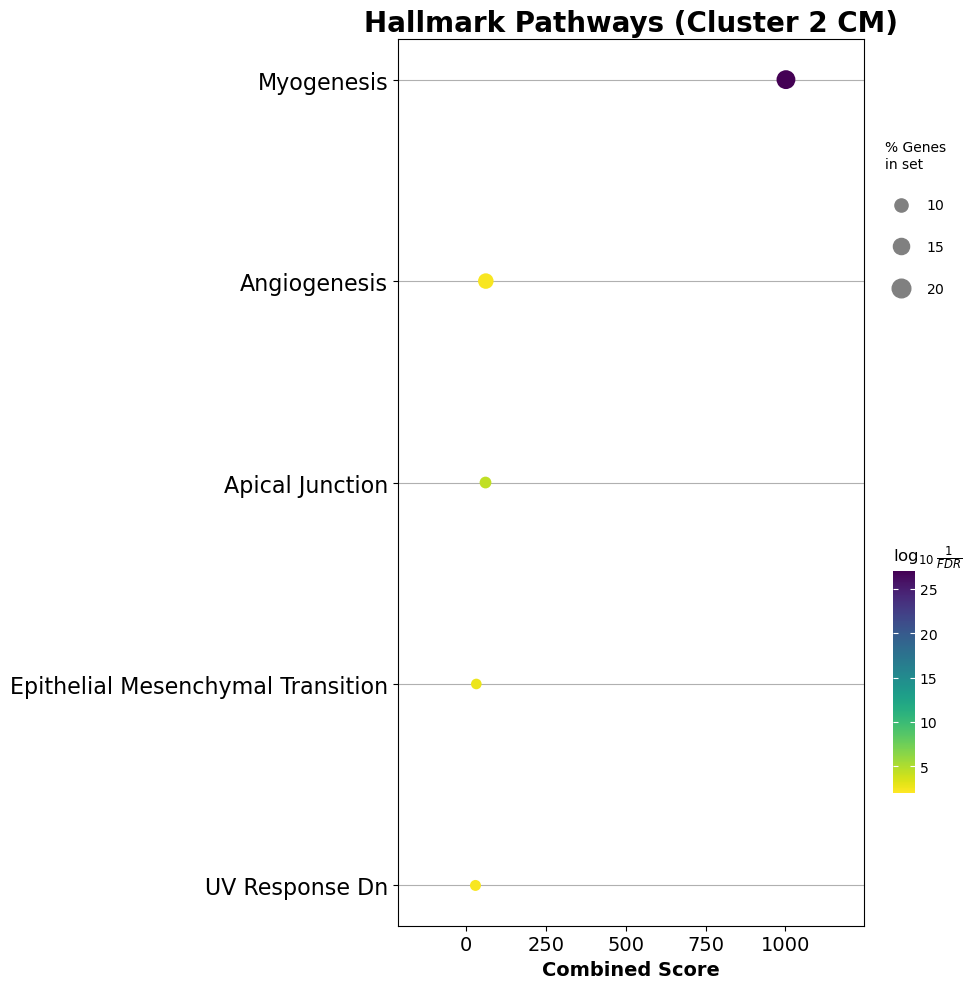

In [34]:
plots_anot(cm_2_ano,cm_2_cut,"Cluster 2 CM")

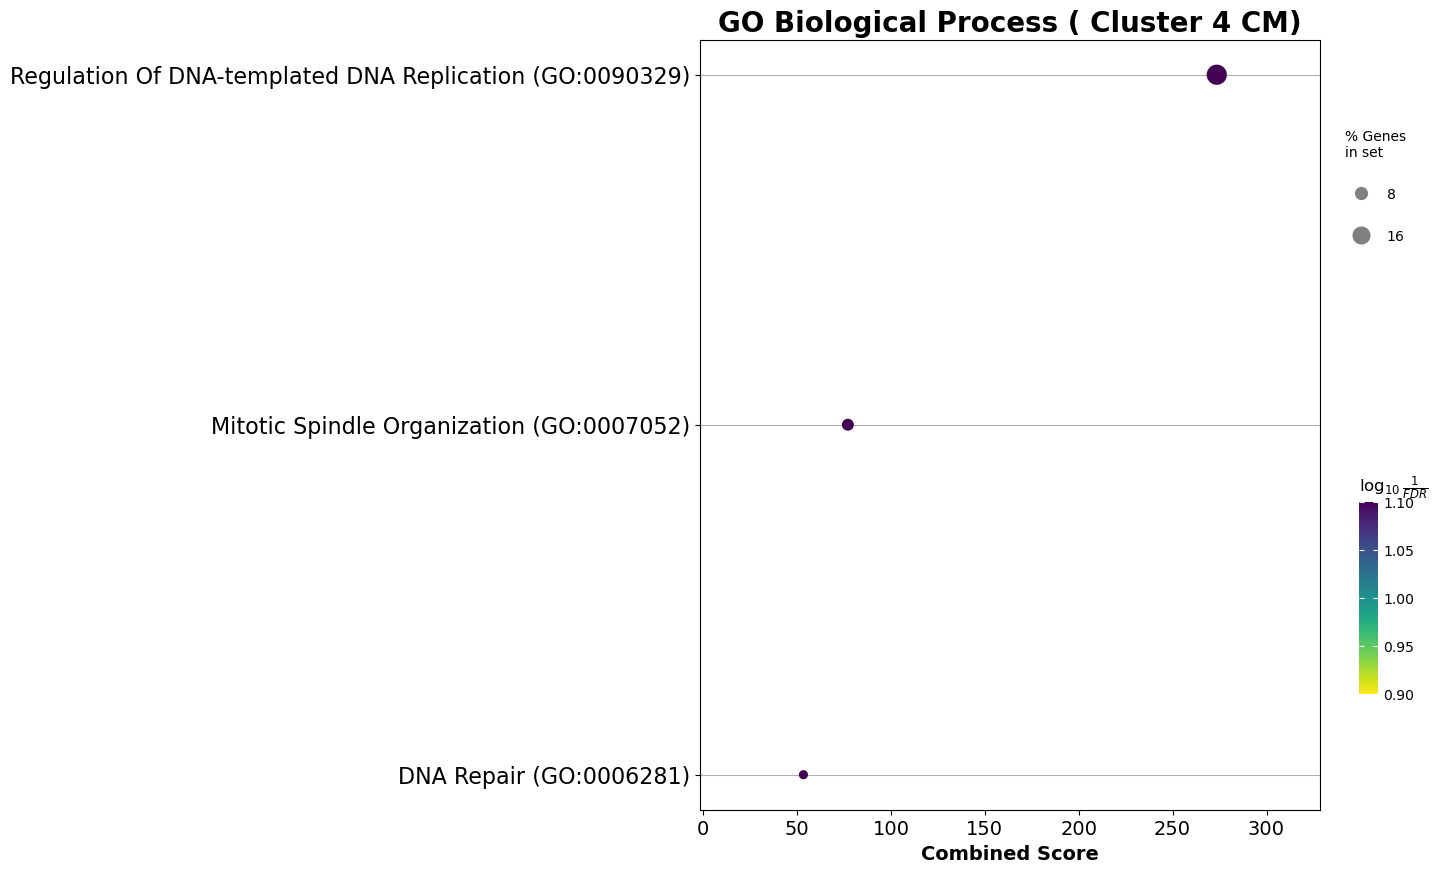

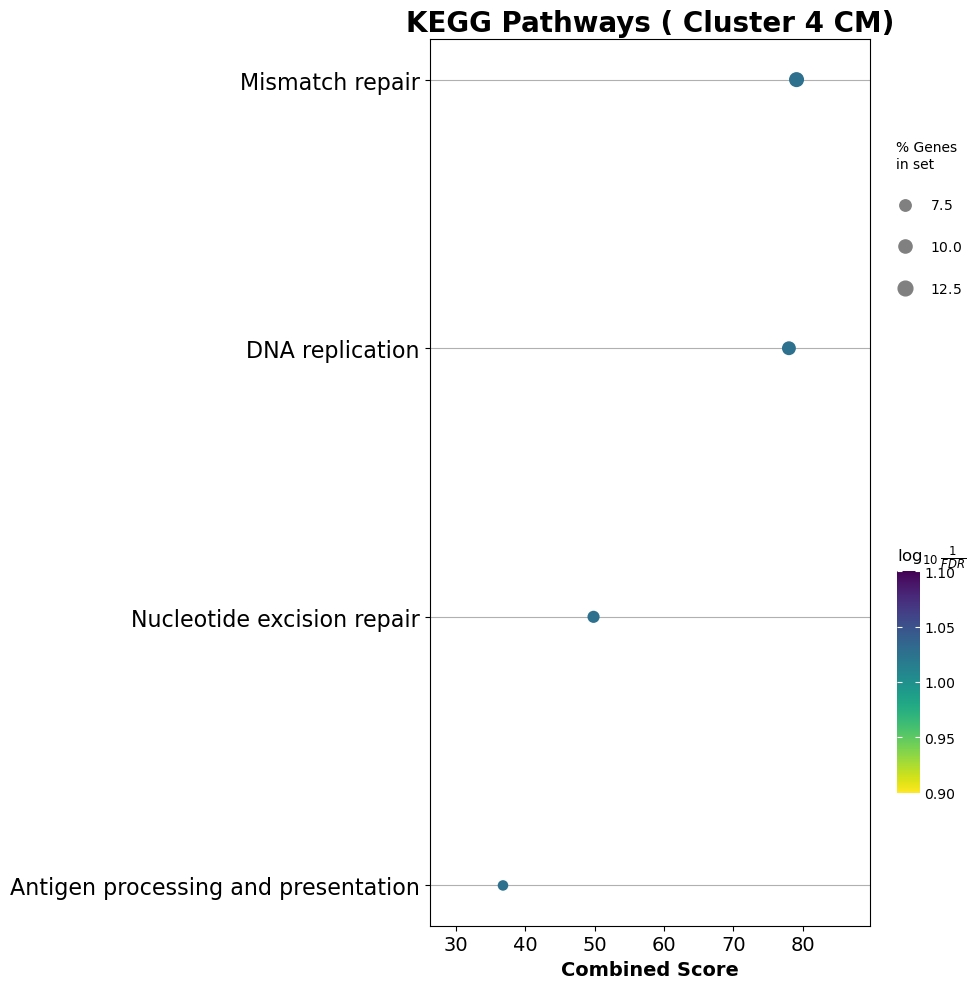

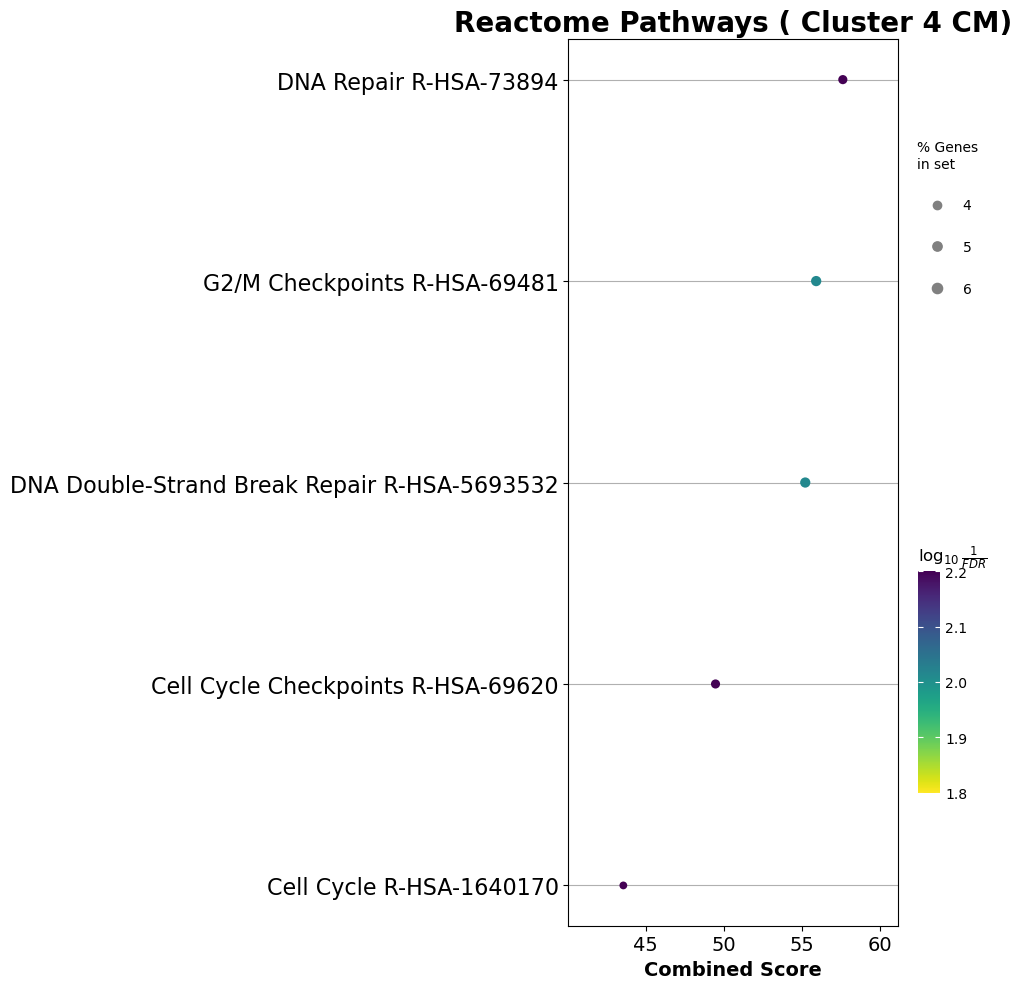

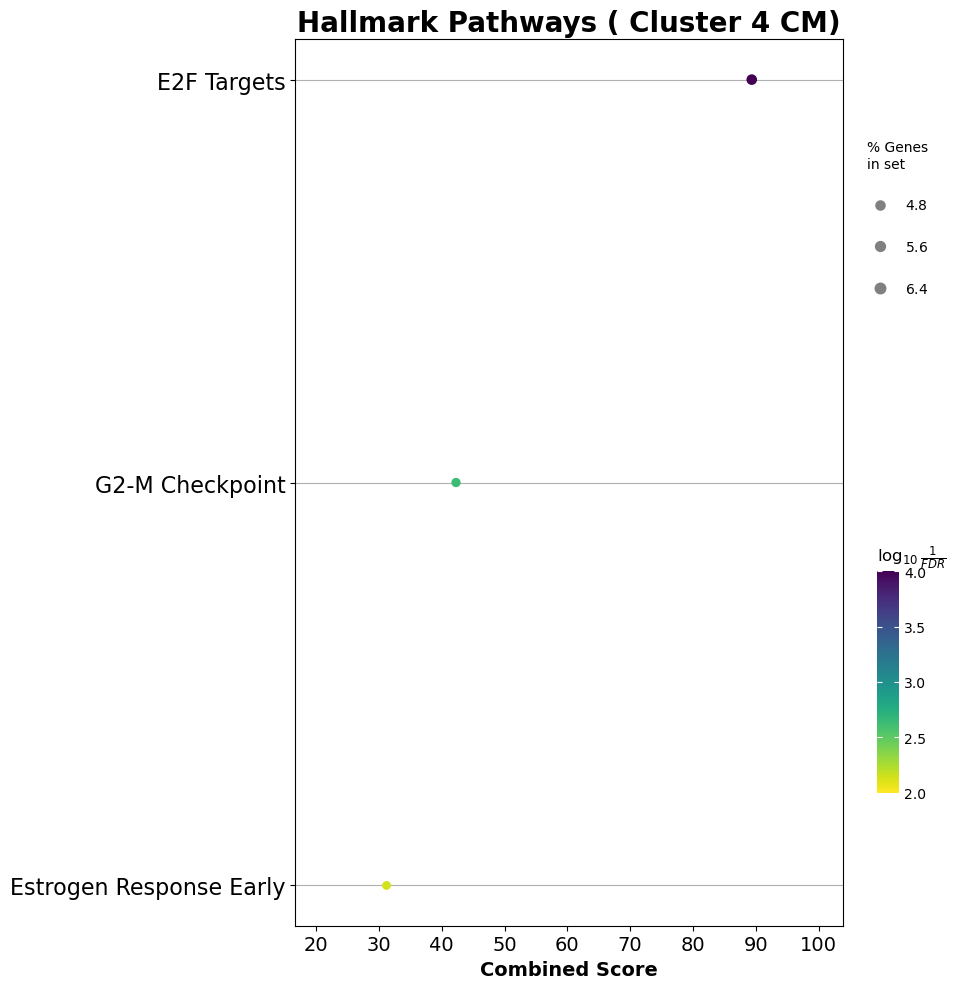

In [35]:
plots_anot(cm_4_ano,cm_4_cut," Cluster 4 CM")

/tmp/ipykernel_27442/1559669188.py:32: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


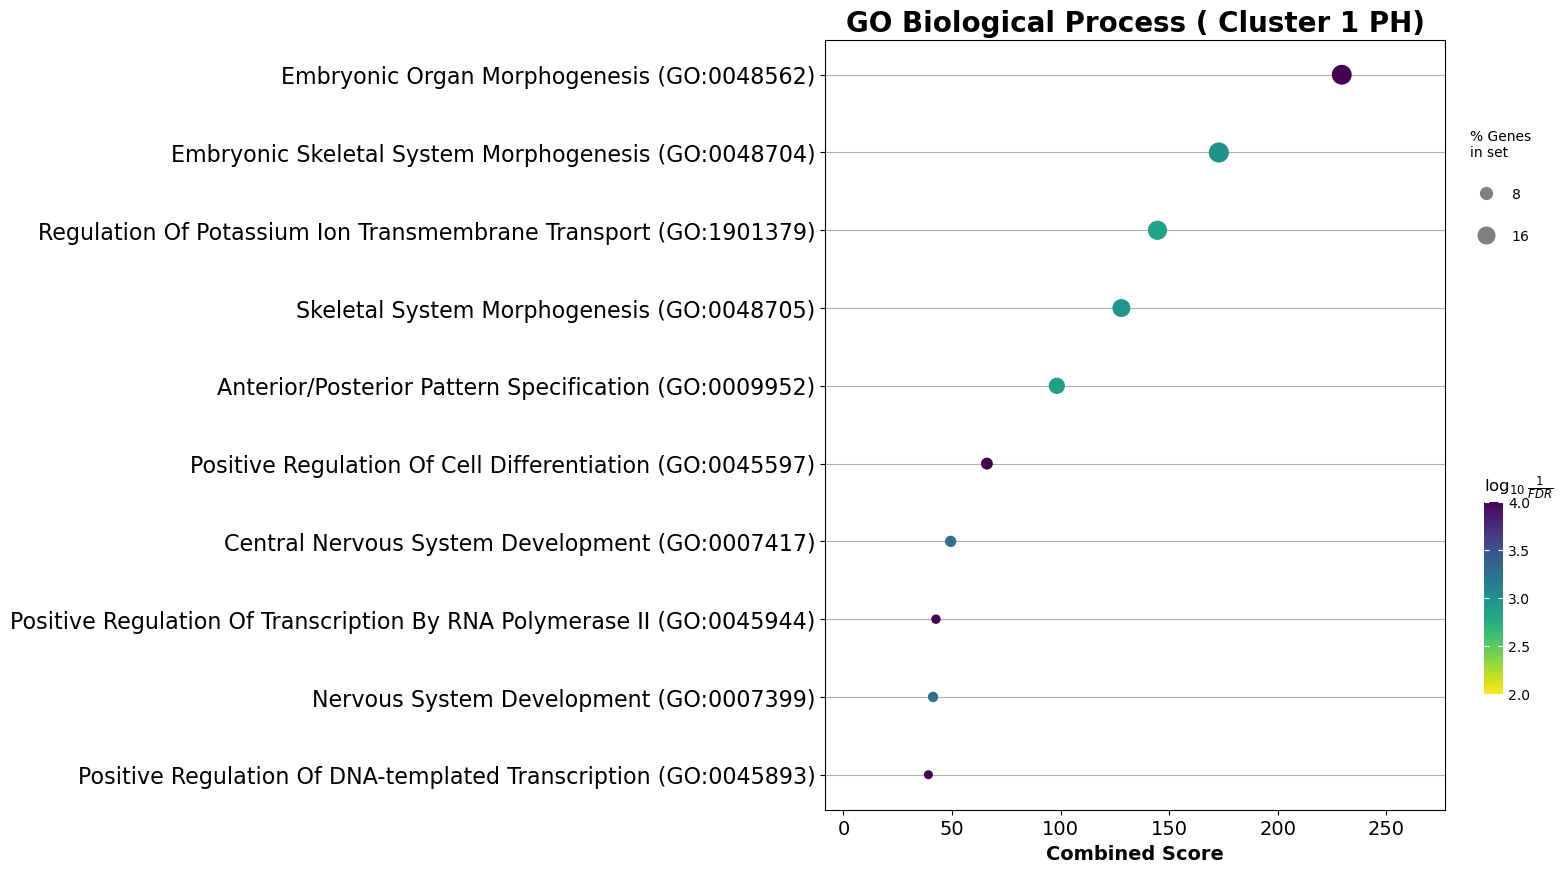

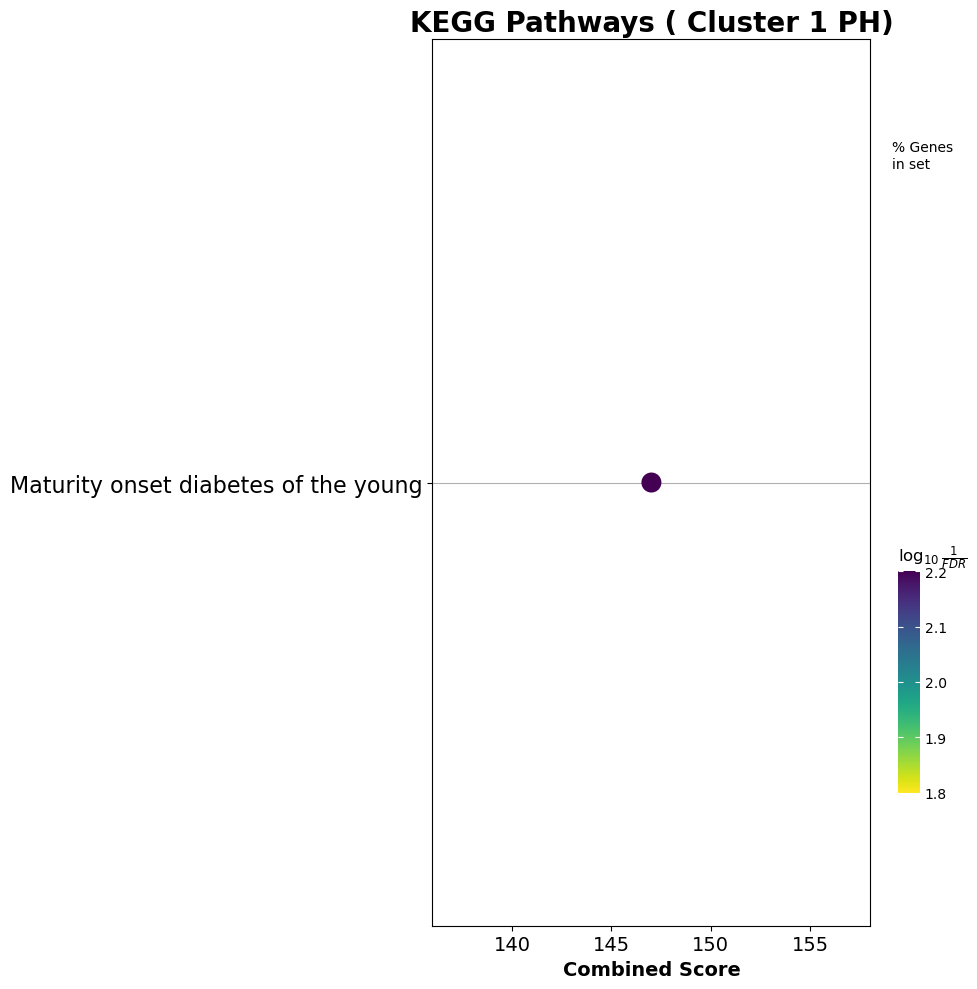

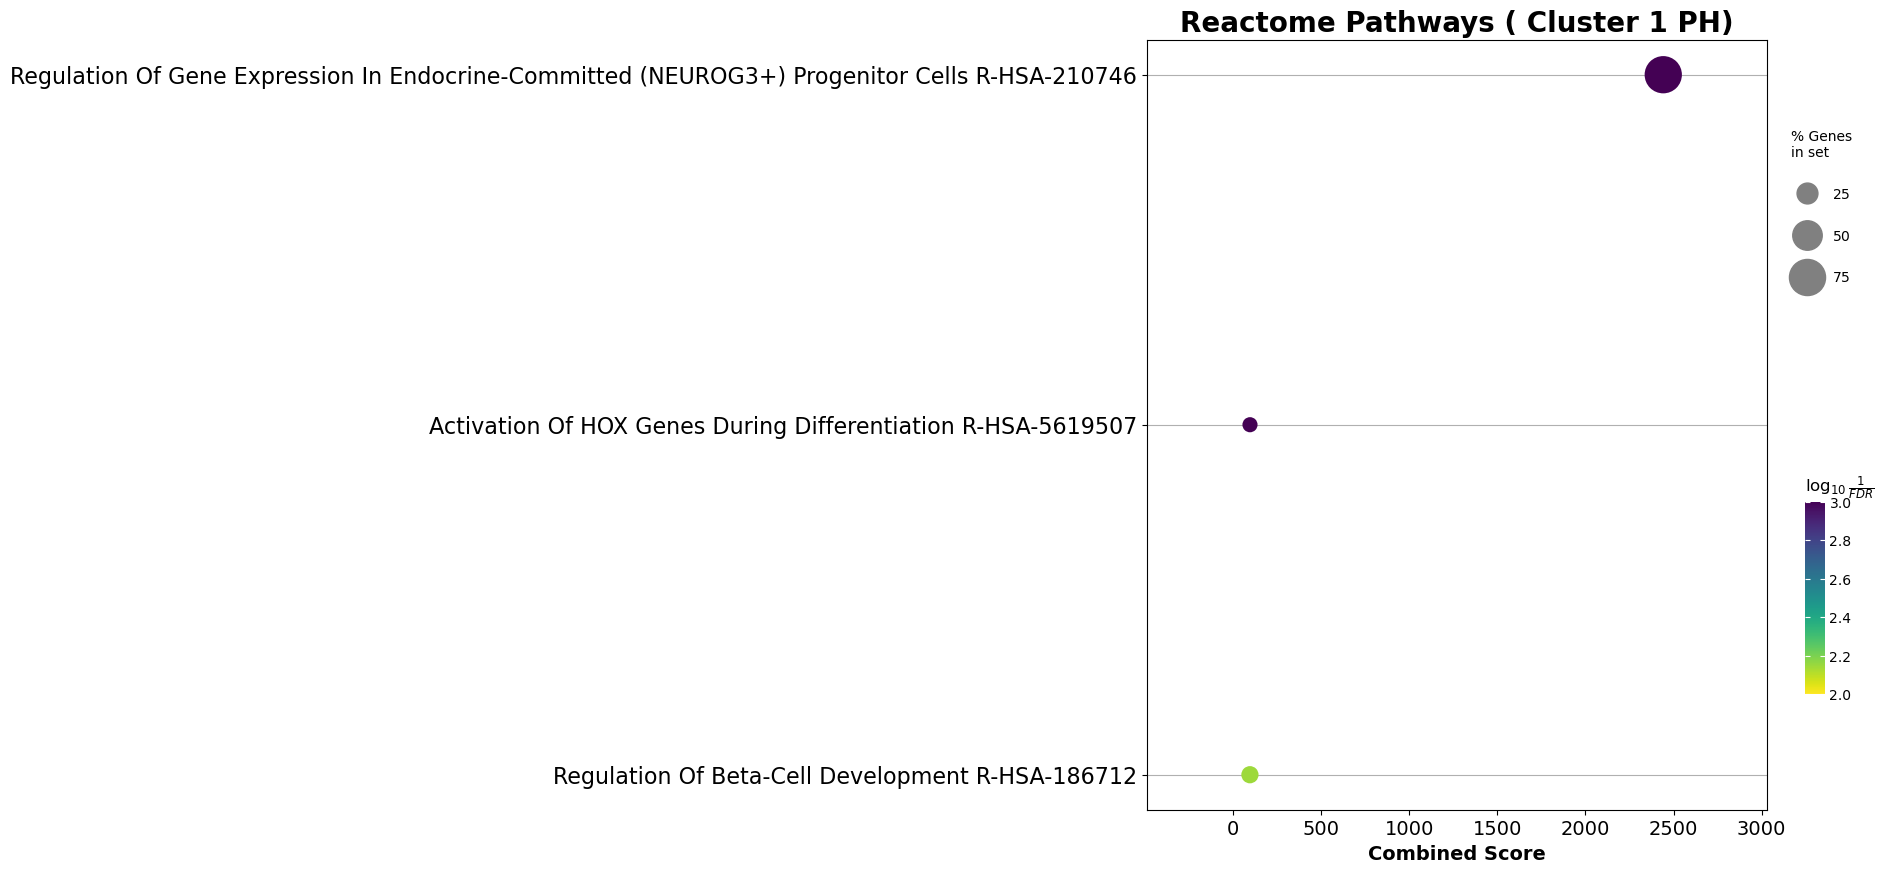

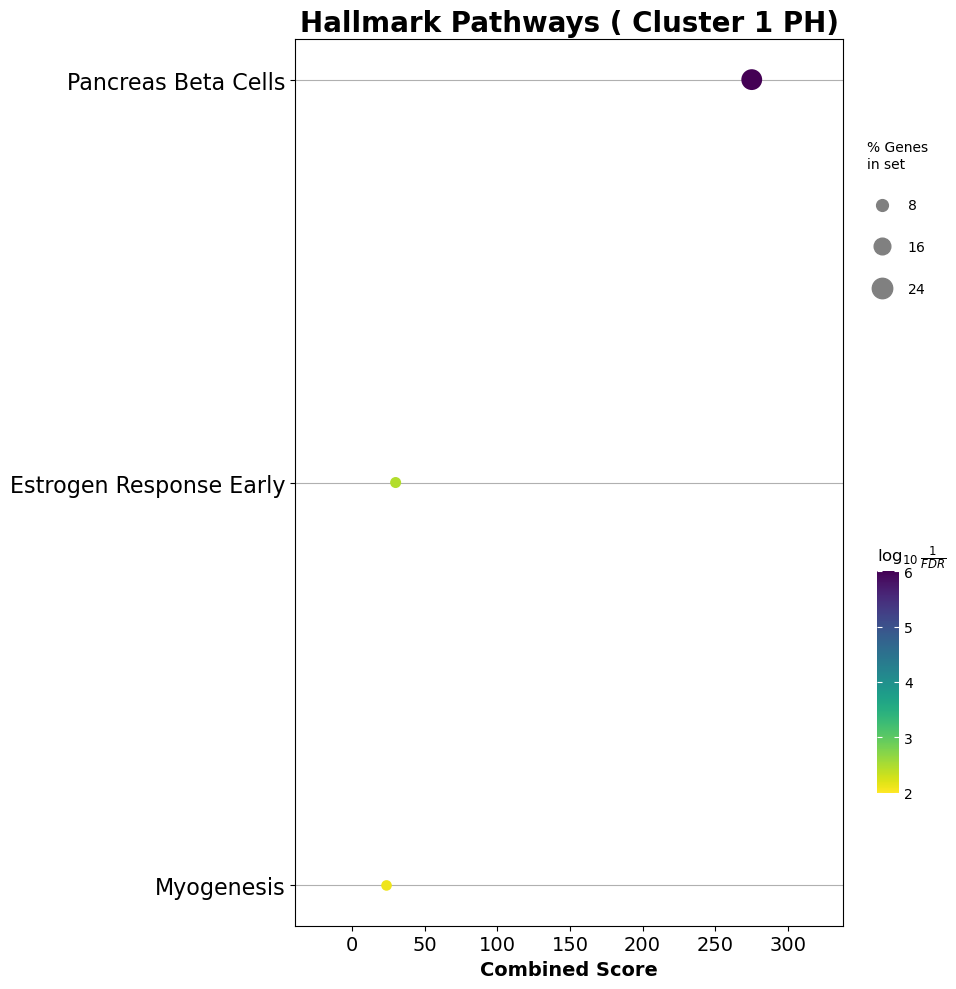

In [36]:
plots_anot(ph_1_ano,ph_1_cut," Cluster 1 PH")

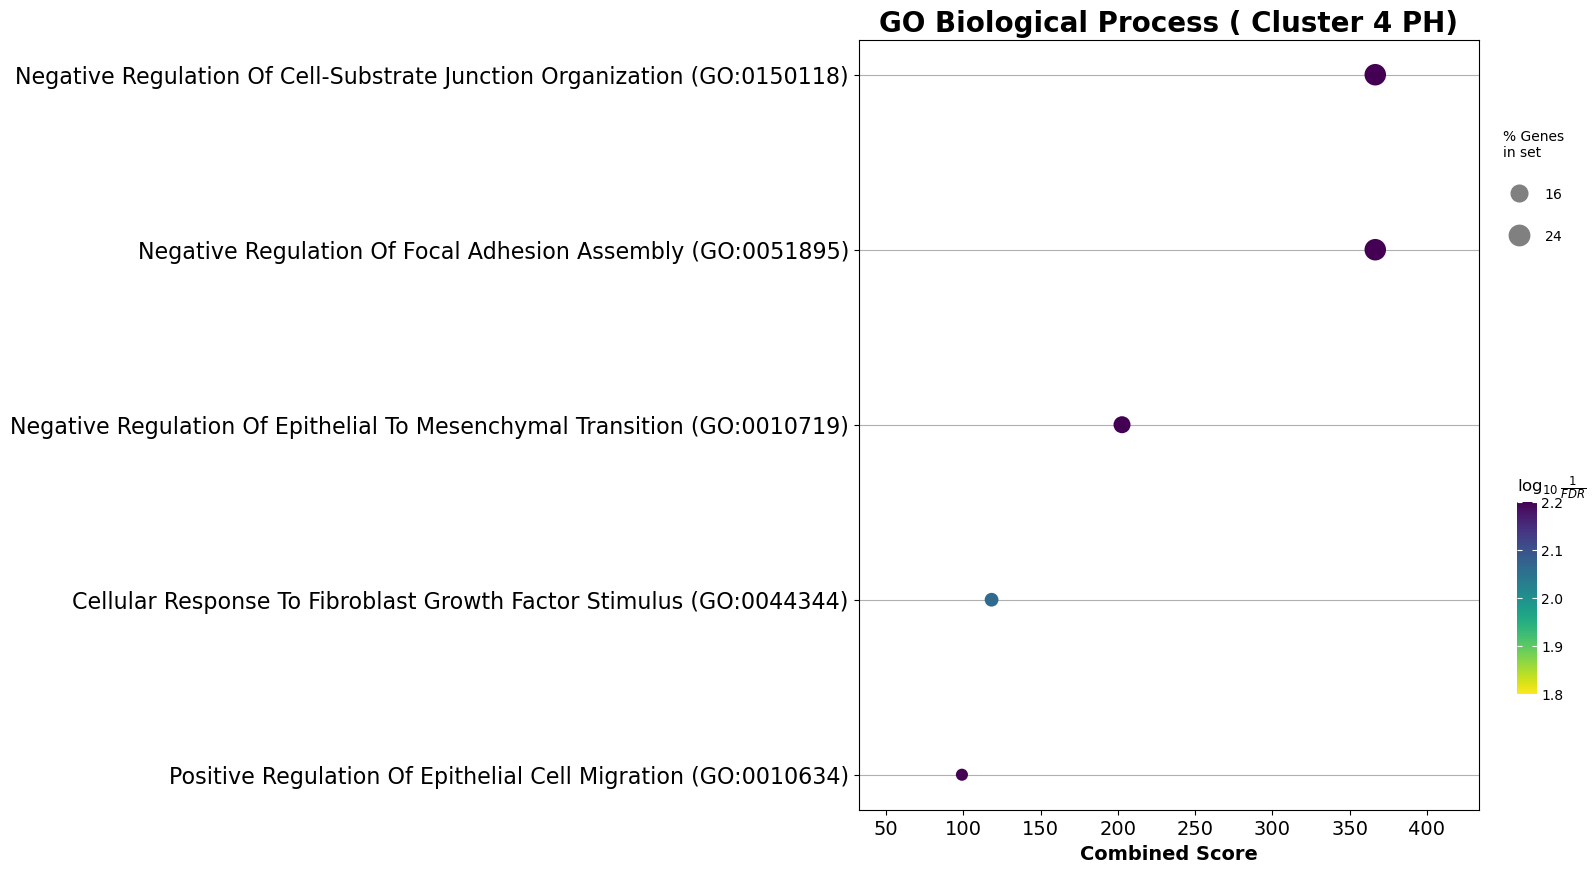

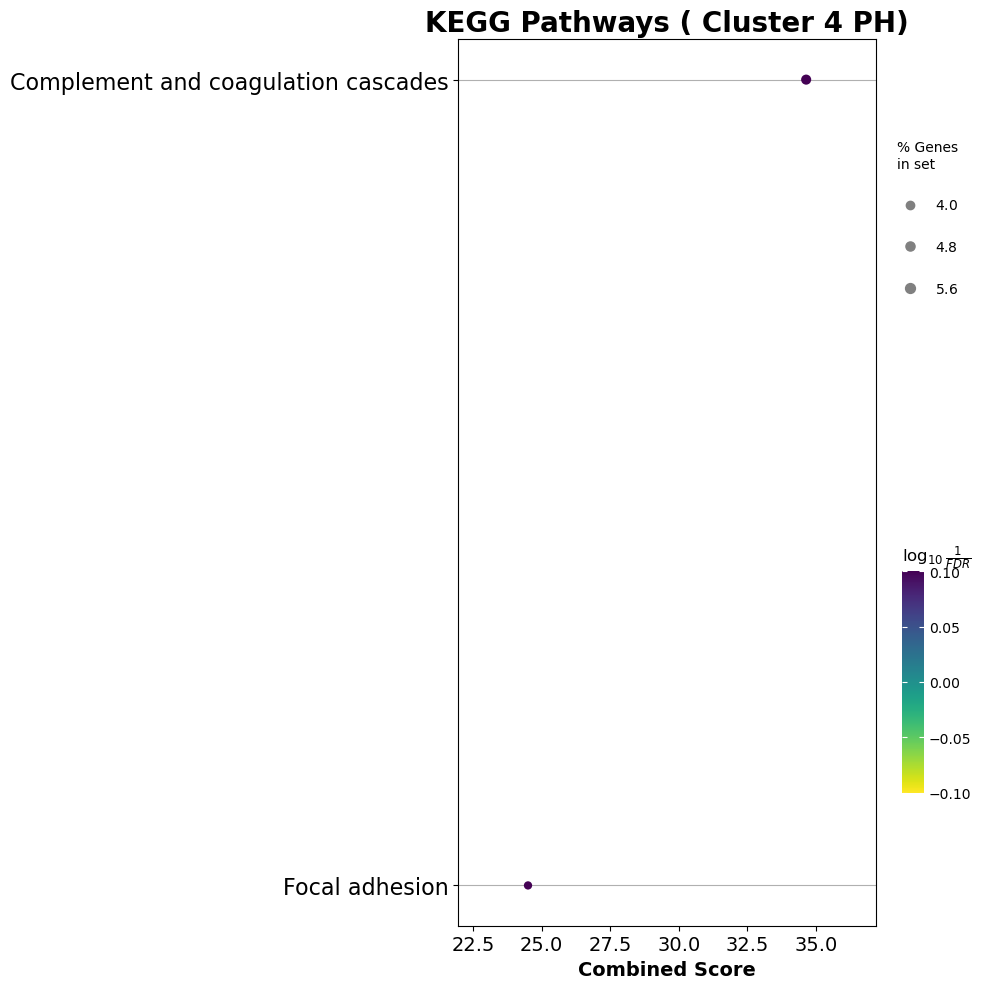

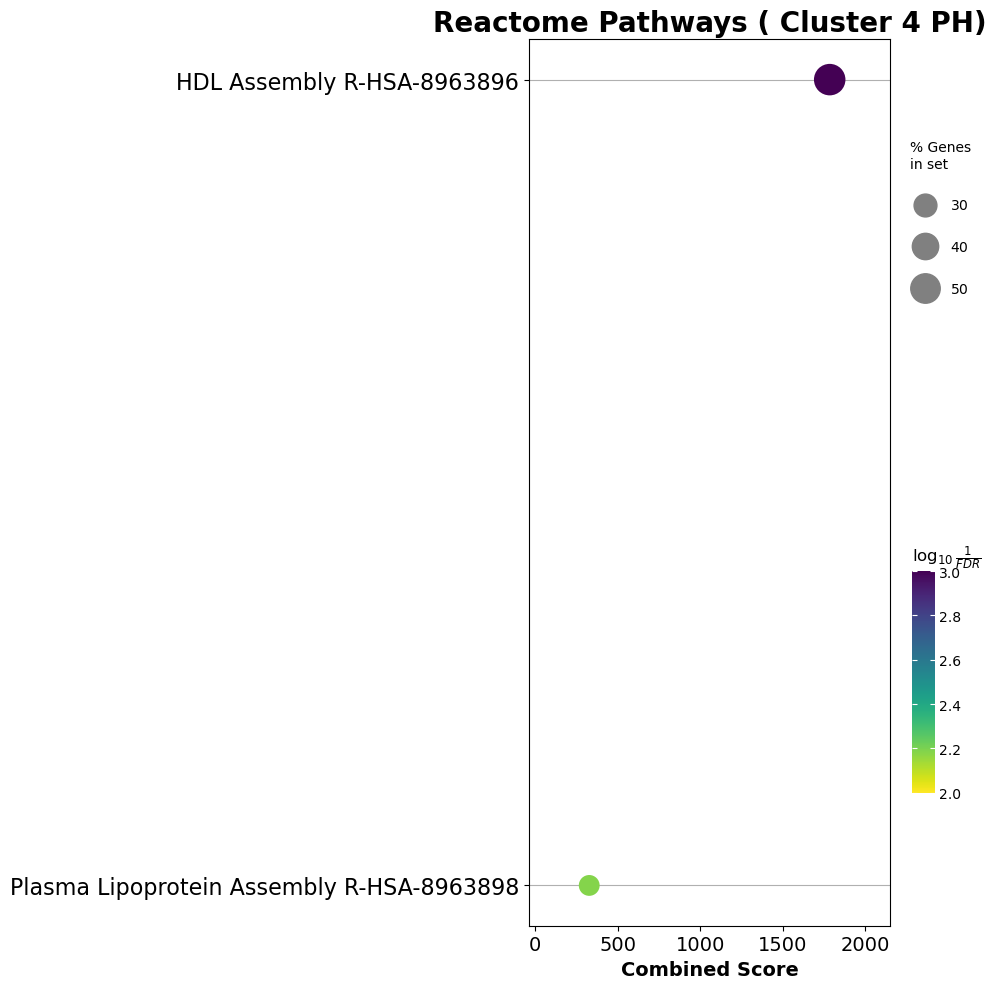

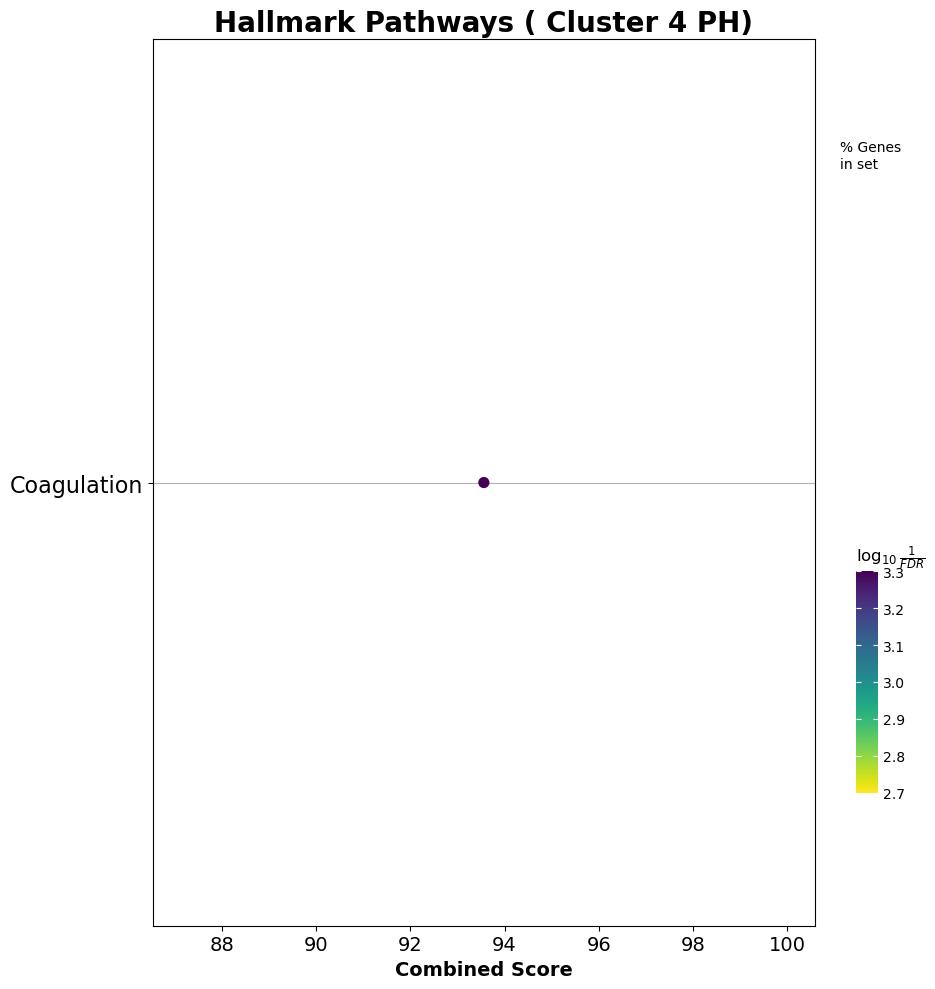

In [37]:
plots_anot(ph_4_ano,ph_4_cut," Cluster 4 PH")

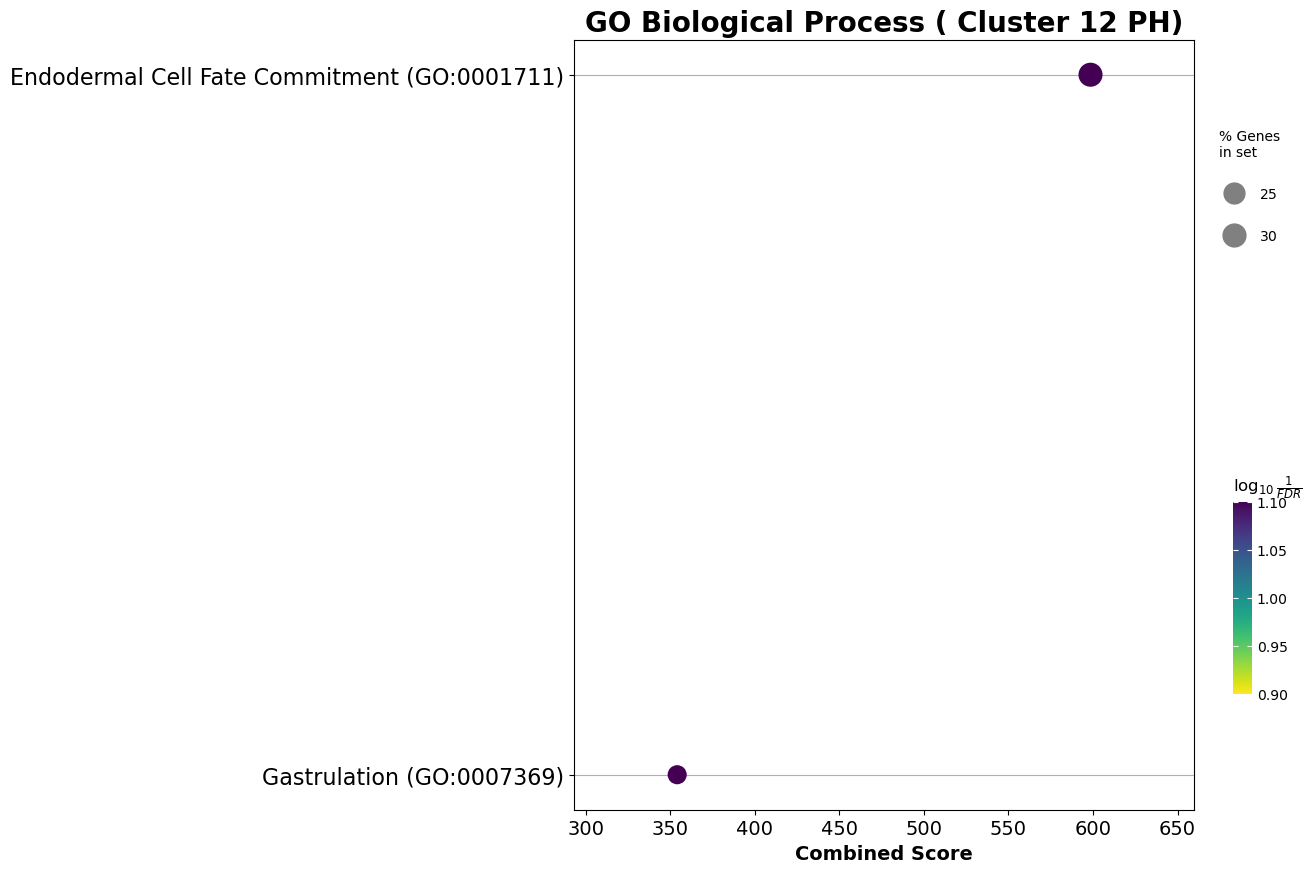

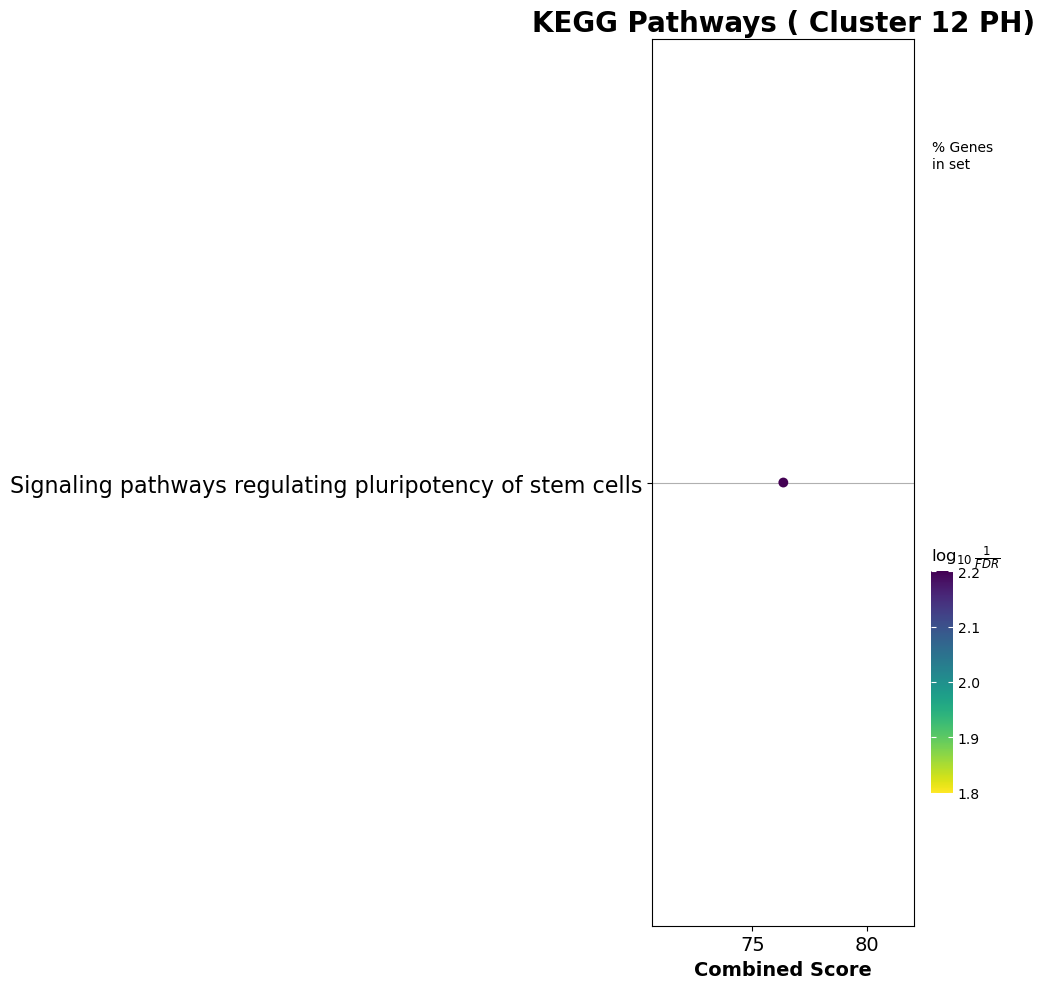

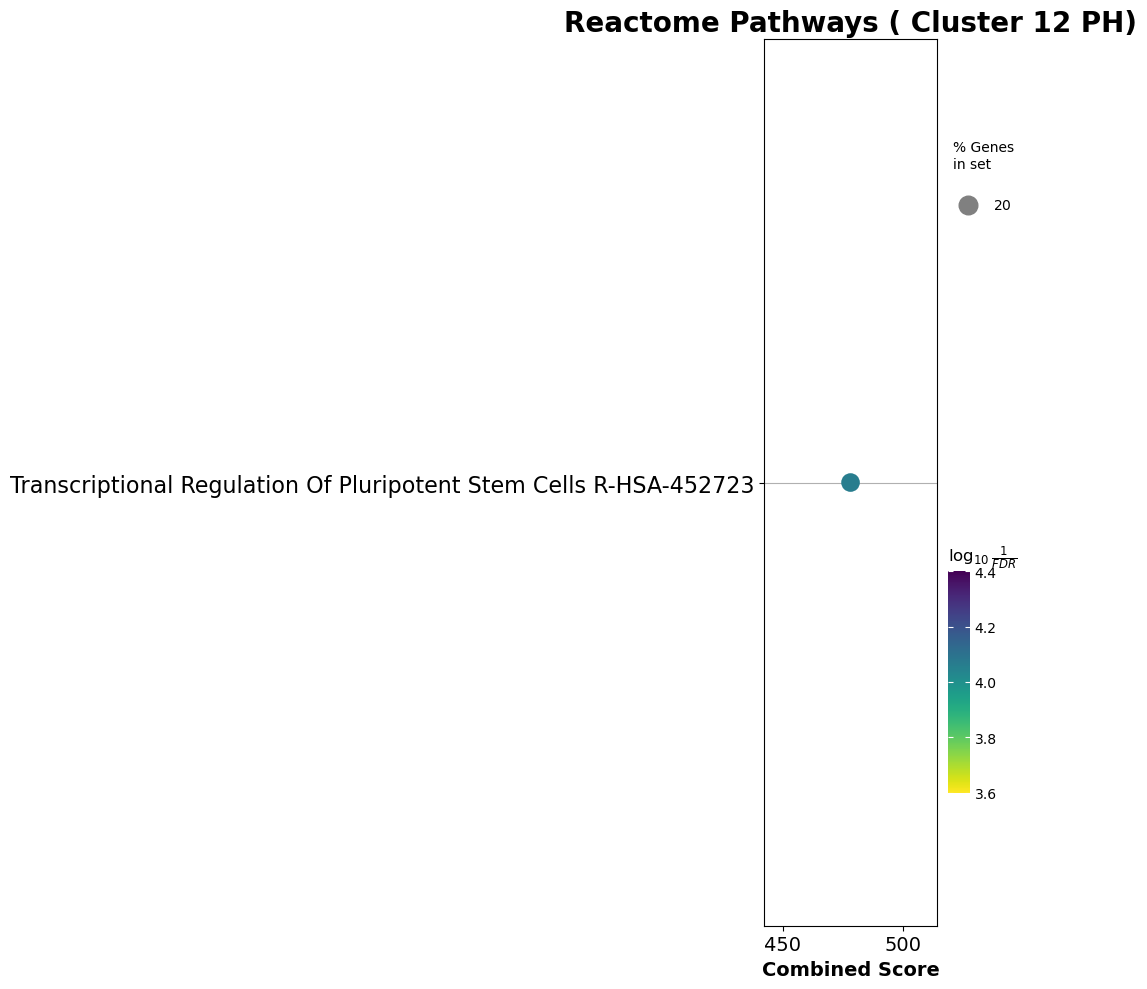

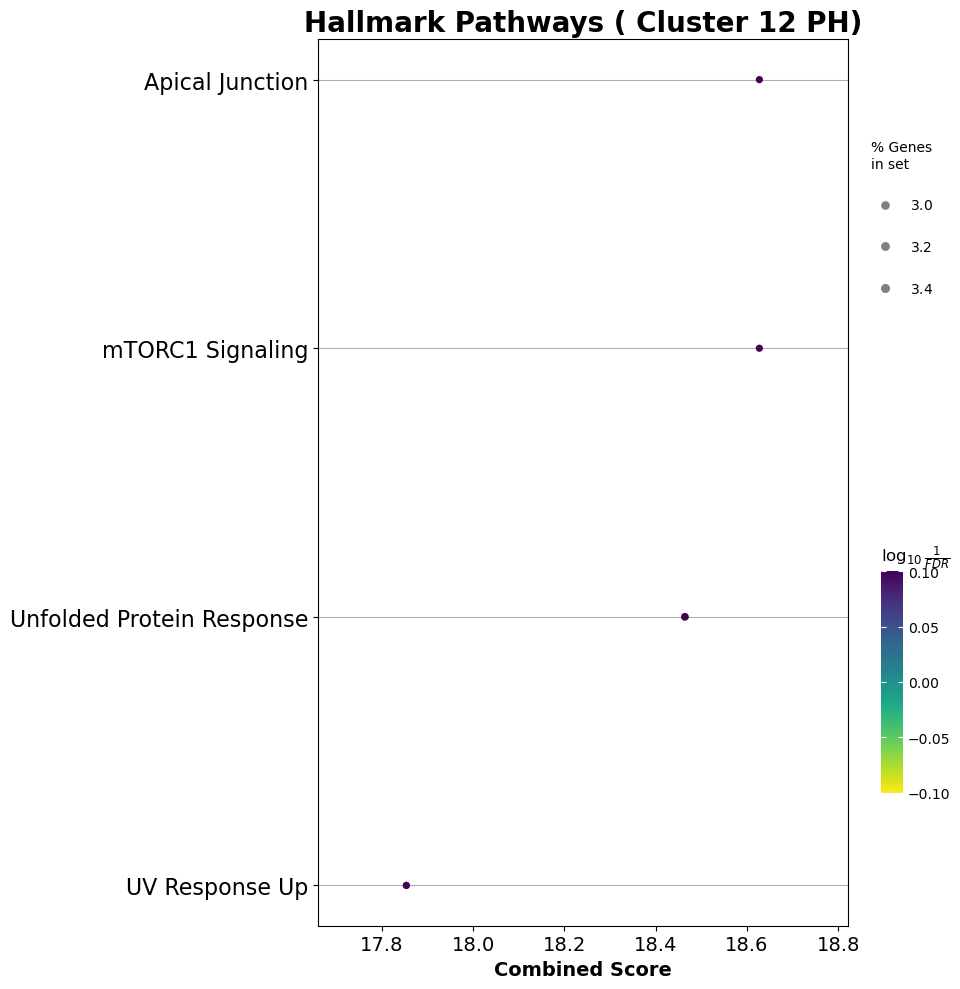

In [38]:
plots_anot(ph_12_ano,ph_12_cut," Cluster 12 PH")